# Пример MPC контроллера с нейронной сетью для моделирования динамики (B747)

Этот пример демонстрирует использование Model Predictive Control (MPC) с нейронной сетью для аппроксимации динамики системы.

## Основные этапы:
1. Создание среды симуляции B747
2. Создание MPC агента с нейросетевой моделью динамики
3. Сбор данных для обучения модели динамики
4. Обучение модели динамики
5. Тестирование системы управления

Используется линеаризованная модель самолета Boeing 747 для продольного движения.

## Импорт необходимых библиотек

Загружаем все необходимые модули для работы с MPC контроллером и моделированием.

In [1]:
import numpy as np
import gymnasium as gym
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

from tensoraerospace.envs.b747 import LinearLongitudinalB747
from tensoraerospace.utils import generate_time_period, convert_tp_to_sec_tp
from tensoraerospace.signals.standart import unit_step
from tensoraerospace.agent.mpc import MPCAgent, MPCWeights, MPCConstraints

2026-04-08 12:57:01.005340: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-08 12:57:01.023644: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-08 12:57:01.023662: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-08 12:57:01.024181: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-08 12:57:01.027324: I tensorflow/core/platform/cpu_feature_guar

## Настройка параметров симуляции

Задаем параметры времени и создаем среду симуляции B747.

**Переменные состояния:**
- `u` — продольная скорость
- `w` — вертикальная скорость
- `q` — угловая скорость тангажа
- `theta` — угол тангажа

**Управляющее воздействие:**
- `stab` — отклонение стабилизатора

In [2]:
# Параметры времени
dt = 0.1
tp = generate_time_period(tn=20, dt=dt)
tps = convert_tp_to_sec_tp(tp, dt=dt)
number_time_steps = len(tp)

# Ступенька на 5 секунде (tp — индексы, не секунды; 5 сек / 0.1 dt = индекс 50)
step_index = int(5.0 / dt)  # = 50

# Заданный сигнал — ступенька 1 градус
reference_signals_rad = np.reshape(
    unit_step(degree=1, tp=tp, time_step=step_index, output_rad=True),
    [1, -1]
)
# Env возвращает theta в градусах, поэтому для MPC x_ref нужны градусы
reference_signals_deg = np.reshape(
    unit_step(degree=1, tp=tp, time_step=step_index, output_rad=False),
    [1, -1]
)

# Создание среды B747
env = gym.make(
    'LinearLongitudinalB747-v0',
    number_time_steps=number_time_steps,
    initial_state=[[0], [0], [0], [0]],
    reference_signal=reference_signals_rad,
    state_space=["u", "w", "q", "theta"],
    control_space=["stab"],
    output_space=["u", "w", "q", "theta"],
    tracking_states=["theta"],
    dt=dt,
)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
print(f"State dim: {state_dim}, Action dim: {action_dim}")
print(f"Ступенька начинается на шаге {step_index} (t = {step_index * dt:.1f} сек)")

State dim: 4, Action dim: 1
Ступенька начинается на шаге 50 (t = 5.0 сек)


## Создание MPC агента

Создаем MPC агент с нейросетевой моделью динамики. Агент автоматически:
- Создает MLP-сеть для аппроксимации динамики
- Настраивает MPC-решатель с заданными весами и ограничениями
- Управляет буфером данных для обучения

**Параметры MPC:**
- `horizon=20`: горизонт планирования
- `Q_diag`: вес ошибки состояния (больше для theta)
- `R_diag`: штраф за управляющее воздействие
- `S_diag`: штраф за изменение управления (гладкость)

In [3]:
# Веса MPC: большой вес на theta (индекс 3), малый на остальные
# R_diag и S_diag увеличены для подавления паразитных колебаний до начала ступеньки
weights = MPCWeights(
    Q_diag=np.array([0.0, 0.0, 0.5, 20.0], dtype=np.float32),
    R_diag=np.array([0.1], dtype=np.float32),
    S_diag=np.array([1.0], dtype=np.float32),
    terminal_weight=2.0,
)

# Ограничения на управление
constraints = MPCConstraints(
    u_min=np.array([-25.0], dtype=np.float32),
    u_max=np.array([25.0], dtype=np.float32),
)

# Создание MPC агента
agent = MPCAgent(
    env,
    horizon=20,
    weights=weights,
    constraints=constraints,
    tracking_type="tracking",
    iters=80,
    mpc_lr=0.03,
    hidden_layers=(256, 256),
    activation="relu",
    normalize=True,
    dynamics_lr=1e-3,
    memory_capacity=200_000,
    device="cpu",
    seed=42,
)

print("MPC агент создан")

MPC агент создан


/home/mr8bit/Projects/TensorAeroSpace/.venv/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.dt to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.dt` for environment variables or `env.get_wrapper_attr('dt')` that will search the reminding wrappers.
  logger.warn(


## Сбор данных для обучения модели динамики

Собираем данные переходов `(x, u, x_next)` через взаимодействие со средой.
Используем два раунда сбора:
1. **Случайные действия** — покрытие различных рабочих точек
2. **Структурированные сигналы** — ступеньки, синусоиды, чирпы и т.д. для захвата динамики на разных частотах и амплитудах

In [5]:
# Раунд 1: случайные действия — широкое покрытие пространства состояний
agent.collect_data(
    num_episodes=100,
    exploration="random",
)
print(f"После random: {len(agent.memory)} переходов")

# Раунд 2: структурированные сигналы — точное моделирование динамики
agent.collect_data(
    num_episodes=10000,
    exploration="signals",
    signal_kinds=[
        "random_steps",      # случайные ступеньки разной амплитуды
        "unit_step",         # единичные ступеньки
        "multi_step",        # несколько ступенек за эпизод
        "ramp",              # линейное нарастание
        "sinusoid",          # синусоиды (основная динамика)
        "multisine",         # сумма синусоид (разные частоты)
        "chirp",             # частотная развёртка
        "square_wave",       # прямоугольные импульсы
        "triangular_wave",   # треугольные волны
        "sawtooth",          # пилообразные волны
        "doublet",           # дублетные импульсы (резкие переключения)
        "pulse",             # одиночные импульсы
        "gaussian_pulse",    # гауссовы импульсы
        "damped_sinusoid",   # затухающие колебания
    ],
    dt=dt,
)
print(f"После signals: {len(agent.memory)} переходов")

Collect episodes: 100%|██████████| 100/100 [00:00<00:00, 122.87it/s]


После random: 200000 переходов


Collect episodes: 100%|██████████| 10000/10000 [00:55<00:00, 179.38it/s]

После signals: 200000 переходов


## Обучение модели динамики

Обучаем нейронную сеть на собранных данных. Модель учится предсказывать
следующее состояние системы `x_{t+1}` по текущему состоянию `x_t` и управлению `u_t`.

In [6]:
# Обучение модели динамики (больше эпох для лучшей точности)
result = agent.train_dynamics(
    epochs=300,
    batch_size=2048,
    loss="mse",
)

print(f"Финальный loss: {result['loss']:.8f}")

Train dynamics: 100%|██████████| 29100/29100 [05:38<00:00, 85.89step/s, loss=2.69e-5] 

Финальный loss: 0.00002690


## Тестирование MPC контроллера

Создаем новую среду для тестирования и запускаем MPC контроллер.
На каждом шаге агент:
1. Наблюдает текущее состояние
2. Формирует опорную траекторию на горизонте планирования
3. Оптимизирует управляющий сигнал через MPC
4. Применяет первый элемент оптимальной последовательности

In [7]:
# Создаем тестовую среду
test_env = gym.make(
    'LinearLongitudinalB747-v0',
    number_time_steps=number_time_steps,
    initial_state=[[0], [0], [0], [0]],
    reference_signal=reference_signals_rad,
    state_space=["u", "w", "q", "theta"],
    control_space=["stab"],
    output_space=["u", "w", "q", "theta"],
    tracking_states=["theta"],
    dt=dt,
)

# Запуск симуляции
obs, info = test_env.reset()
agent.reset()

states_hist = [obs.flatten()]
controls_hist = []
horizon = agent.mpc.horizon

for step in tqdm(range(number_time_steps - 2)):
    # Текущее значение задания (без заглядывания в будущее)
    current_ref = reference_signals_deg[0, step]

    # x_ref: текущее задание повторяется на весь горизонт
    # Это предотвращает упреждающую реакцию MPC на будущие изменения
    x_ref = np.zeros((horizon + 1, state_dim), dtype=np.float32)
    x_ref[:, 3] = current_ref  # theta = const на горизонте

    action = agent.select_action(obs.flatten(), x_ref=x_ref)
    obs, reward, terminated, truncated, info = test_env.step(action)

    states_hist.append(obs.flatten())
    controls_hist.append(action)

    if terminated or truncated:
        break

states_hist = np.array(states_hist)
controls_hist = np.array(controls_hist)
print(f"Симуляция завершена: {len(controls_hist)} шагов")

 99%|█████████▉| 198/199 [00:32<00:00,  6.18it/s]

Симуляция завершена: 199 шагов


## Визуализация результатов

Построим графики переходного процесса и управляющего сигнала.

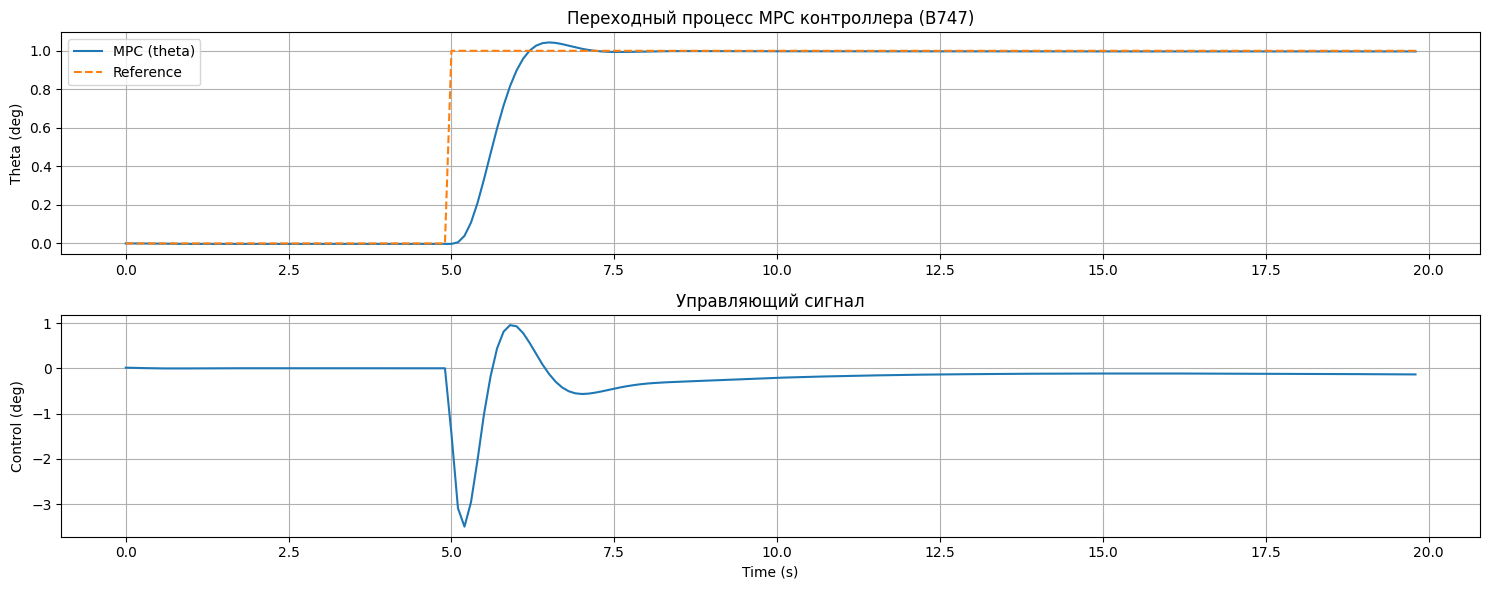

In [8]:
n_steps = len(controls_hist)
time_array = np.arange(n_steps) * dt

# Угол theta из истории состояний (индекс 3) — уже в градусах из env
theta_hist = states_hist[:n_steps, 3]
theta_ref = reference_signals_deg[0, :n_steps]

plt.figure(figsize=(15, 6))

plt.subplot(2, 1, 1)
plt.plot(time_array, theta_hist, label="MPC (theta)")
plt.plot(time_array, theta_ref, '--', label="Reference")
plt.ylabel("Theta (deg)")
plt.legend()
plt.title("Переходный процесс MPC контроллера (B747)")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(time_array, controls_hist)
plt.xlabel("Time (s)")
plt.ylabel("Control (deg)")
plt.title("Управляющий сигнал")
plt.grid(True)

plt.tight_layout()
plt.show()

In [9]:
from tensoraerospace.benchmark import ControlBenchmark

bench = ControlBenchmark()
res = bench.becnchmarking_one_step(theta_ref, theta_hist, 0.9, dt)
res

{'overshoot': 4.3616414070129395,
 'settling_time': 1.1,
 'damping_degree': 0.014909943,
 'static_error': 0.0031296610832214355,
 'rise_time': 0.8,
 'peak_time': 1.5,
 'maximum_deviation': 1.0024954,
 'iae': 7.466929513728246,
 'ise': 5.362765379504178,
 'itae': 5.9425986013840895,
 'oscillation_count': 2,
 'steady_state_value': 1.0,
 'performance_index': 5.394473873757895}

In [10]:
print("Статическая ошибка: ", res['static_error'])
print("Время переходного процесса: ", res['settling_time'], "сек")
print("Степень затухания: ", res['damping_degree'])
print("Перерегулирование: ", res['overshoot'])

Статическая ошибка:  0.0031296610832214355
Время переходного процесса:  1.1 сек
Степень затухания:  0.014909943
Перерегулирование:  4.3616414070129395


## Детальный анализ переходного процесса

Используем встроенный бенчмарк для визуализации качества управления.

In [11]:
bench.plot(theta_ref, theta_hist, 0.9, dt, time_array, figsize=(15, 5))

{'overshoot': 4.3616414070129395,
 'settling_time': 1.1,
 'damping_degree': 0.014909943,
 'static_error': 0.0031296610832214355,
 'rise_time': 0.8,
 'peak_time': 1.5,
 'maximum_deviation': 1.0024954,
 'iae': 7.466929513728246,
 'ise': 5.362765379504178,
 'itae': 5.9425986013840895,
 'oscillation_count': 2,
 'steady_state_value': 1.0,
 'performance_index': 5.394473873757895}

## Заключение

В данном примере мы продемонстрировали полный цикл разработки MPC контроллера для управления самолетом B747:

1. **Сбор данных** — собрали переходы из среды для обучения модели динамики
2. **Обучение нейронной сети** — создали модель динамики на основе данных
3. **Создание MPC контроллера** — настроили параметры прогнозирующего управления
4. **Тестирование системы** — проверили качество управления на тестовых данных

Данный подход может быть адаптирован для других типов летательных аппаратов и задач управления.